# 유가 예측 프로젝트 - EDA

**데이터**: `Cleaning data_fix.csv` (2007.08 ~ 2026.03, 거래일 기준 5,069행)  
**타겟 변수**: `oil_return_shift` (내일의 유가 수익률)

| 구간 | 기간 |
|------|------|
| Train | 2007.01 ~ 2019.12 |
| Valid | 2020.01 ~ 2023.12 |
| Test  | 2024.01 ~ 2026.03 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# 맥OS 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

---
## 1. 데이터 로드 & 기본 확인

In [2]:
raw = pd.read_csv('../datas/Finance_Final/Cleaning data_fix.csv', parse_dates=['date'], encoding='cp949')
print(raw.shape)
raw.head(3)

(7382, 44)


,date,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,...,inventory_change,termspread_change,termspread_inversion,TermSpread_sign,OPEC_prod_change,is_monday,is_friday,is_trading_day,is_non_trading_day,missing_reason
0,2006-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,二쇰_(鍮_굅__)
1,2006-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,誘멸뎅 곕갑怨듯_
2,2006-01-03,63.11,2.064842,199.3,100.7558,11.14,98.1999,NaN,NaN,33237.829,...,NaN,NaN,0.0,1.0,NaN,0.0,0.0,1.0,0,NaN


In [3]:
# 거래일만 필터링
df = raw[raw['is_trading_day'] == 1].copy()
df = df.set_index('date').sort_index()
print(df.shape)

(5069, 43)


In [4]:
# 결측치 비율 확인
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_reason             100.00
CPE                          4.91
oil_volatility_20_shift      0.41
OPEC_prod_change             0.39
MA_20_shift                  0.39
oil_volatility_20            0.39
MA_20                        0.37
MA_ratio                     0.37
vix_change                   0.16
oil_return_lag5_shift        0.14
oil_return_lag5              0.12
oil_volatility_5_shift       0.12
MA_5_shift                   0.10
oil_volatility_5             0.10
inventory_change             0.08
VIX                          0.08
MA_5                         0.08
oil_return_lag1_shift        0.06
OilProduction                0.06
OilInventories               0.06
oil_return_shift             0.04
oil_return_lag1              0.04
dollar_return                0.02
oil_return                   0.02
termspread_change            0.02
dtype: float64

In [5]:
train = df.loc['2007-01-02':'2019-12-31']
valid = df.loc['2020-01-01':'2023-12-31']
test  = df.loc['2024-01-01':]

print(f'Train : {train.index.min().date()} ~ {train.index.max().date()} ({len(train)} rows)')
print(f'Valid : {valid.index.min().date()} ~ {valid.index.max().date()} ({len(valid)} rows)')
print(f'Test  : {test.index.min().date()} ~ {test.index.max().date()} ({len(test)} rows)')

Train : 2007-01-02 ~ 2019-12-31 (3270 rows)
Valid : 2020-01-02 ~ 2023-12-29 (1002 rows)
Test  : 2024-01-02 ~ 2026-03-16 (548 rows)


In [6]:
# shift 컬럼은 타겟 계열 → 피처에서 제외
FEATURES = [
    # 모멘텀
    'oil_return_lag1',       # OilPrice.pct_change().shift(1)        → 전일 유가 수익률
    'oil_return_lag5',       # OilPrice.pct_change().shift(5)        → 5거래일 전 유가 수익률
    'oil_volatility_5',      # oil_return.rolling(5).std()           → 최근 5일 수익률 표준편차
    'oil_volatility_20',     # oil_return.rolling(20).std()          → 최근 20일 수익률 표준편차
    'MA_ratio',              # MA_5 / MA_20                          → 단기(5일)/장기(20일) 이동평균 비율
    # 시장심리
    'vix_change',            # VIX.diff()                            → VIX 전일 대비 변화량
    'vix_over_30',           # (VIX > 30).astype(int)                → 시장 공포 구간 더미 (1=공포)
    'dollar_return',         # DollarIndex.pct_change()              → 달러지수 일간 변화율
    # 공급
    'inventory_change',      # OilInventories.diff()                 → 원유 재고 전일 대비 변화량
    'OPEC_prod_change',      # OPECProduction.pct_change()           → OPEC 생산량 변화율
    # 거시경제
    'TermSpread',            # 원본 그대로 사용                      → 장단기 금리차 (10Y - 2Y)
    'termspread_change',     # TermSpread.diff()                     → TermSpread 전일 대비 변화량
    'termspread_inversion',  # (TermSpread < 0).astype(int)          → 금리 역전 더미 (1=역전)
    'FedFundsRate',          # 원본 그대로 사용                      → 연방기금금리
]
TARGET = 'oil_return_shift'  # OilPrice.pct_change().shift(1) 기준 → 다음 거래일 유가 수익률 (예측 대상)

train_feat = train[FEATURES + [TARGET]].dropna()
print(train_feat.shape)

(3263, 15)


---
## 2. 유가 시계열 시각화

train / valid / test1~3 구간을 색상으로 구분하고 주요 이벤트 시점을 수직선으로 표시

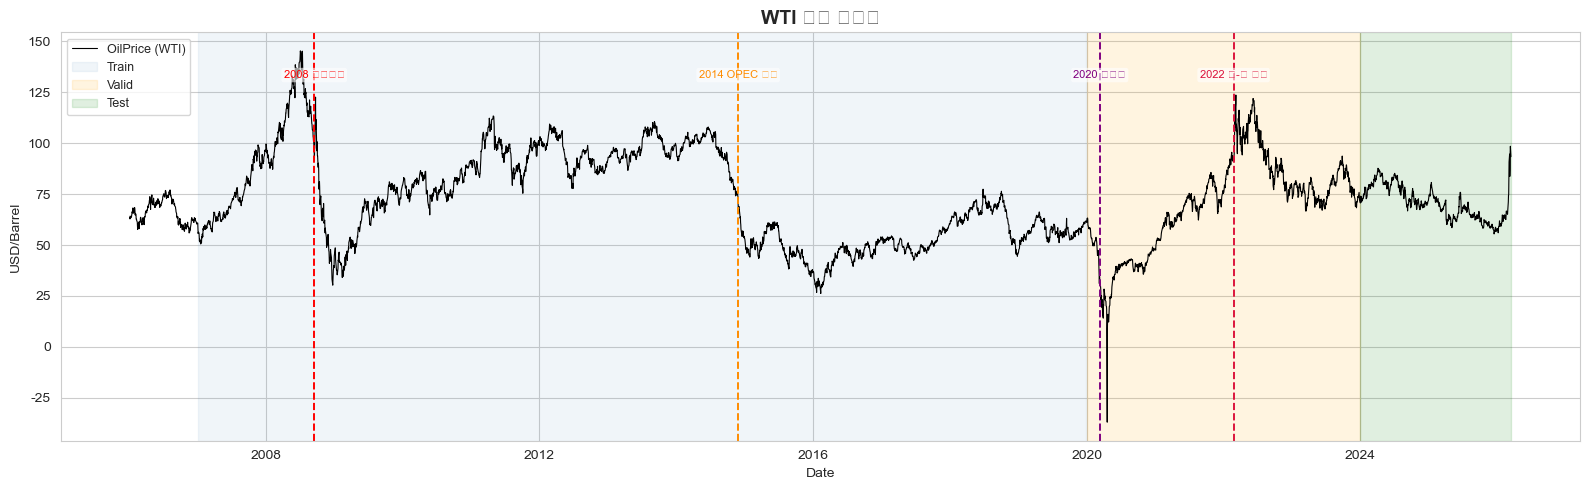

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))

oil = df['OilPrice'].dropna()
ax.plot(oil.index, oil.values, color='black', linewidth=0.8, label='OilPrice (WTI)')

ymin, ymax = ax.get_ylim()
ax.axvspan(train.index.min(), train.index.max(), alpha=0.08, color='steelblue', label='Train')
ax.axvspan(valid.index.min(), valid.index.max(), alpha=0.12, color='orange',    label='Valid')
ax.axvspan(test.index.min(),  test.index.max(),  alpha=0.12, color='green',     label='Test')

events = {
    '2008-09-15': ('2008 금융위기',   'red'),
    '2014-11-27': ('2014 OPEC 감산', 'darkorange'),
    '2020-03-11': ('2020 코로나',     'purple'),
    '2022-02-24': ('2022 러-우 전쟁', 'crimson'),
}
for date_str, (label, color) in events.items():
    ax.axvline(pd.Timestamp(date_str), color=color, linestyle='--', linewidth=1.4)
    ax.text(pd.Timestamp(date_str), ymax * 0.88, label,
            fontsize=8, color=color, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

ax.set_title('WTI 유가 시계열', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('USD/Barrel')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

* 2008년 금융위기 전후로 급등락이 가장 두드러짐
* 2014년 OPEC 감산 발표 이후 공급 과잉으로 급락
* 2020년 코로나로 역사적 저점 기록, 2022년 러-우 전쟁으로 급등

---
## 3. 거시경제 지표 시계열 시각화

파생변수 생성 전 **원본 지표**들의 시계열 흐름을 확인한다.  
train / valid / test 구간을 배경색으로 구분하여 구간별 특성을 파악한다.

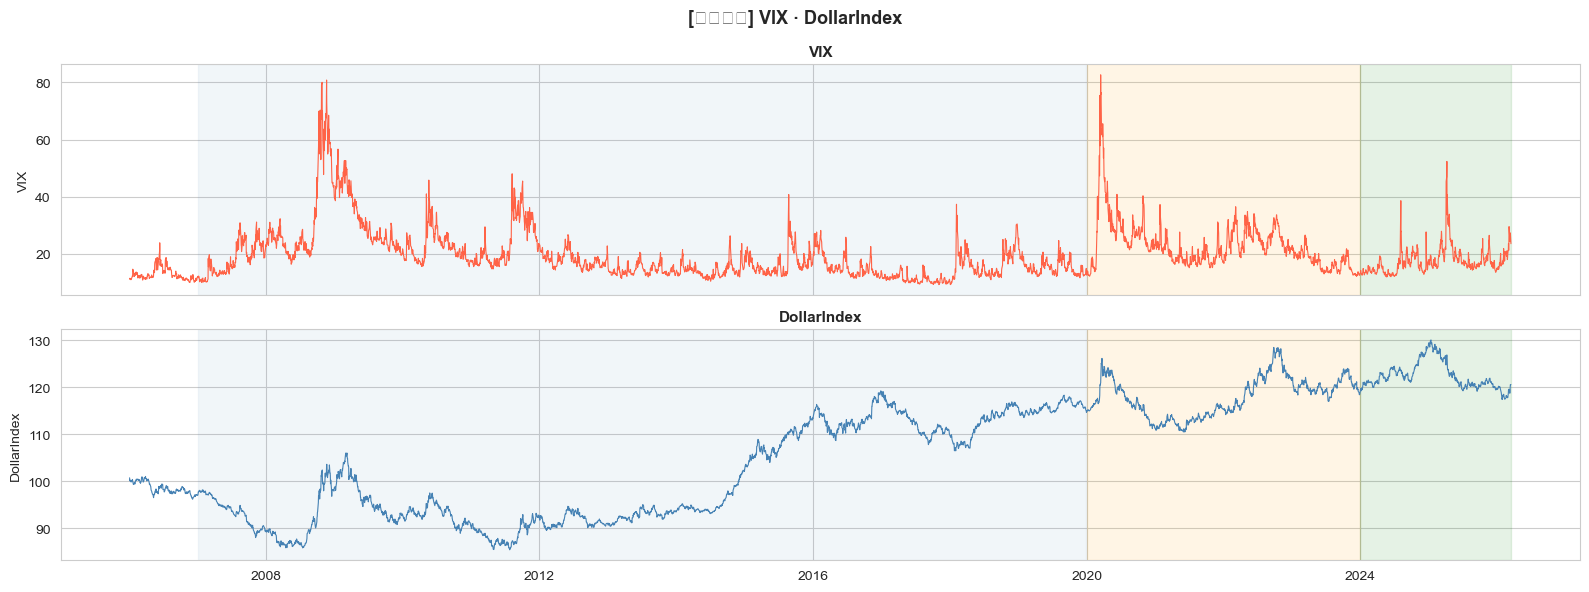

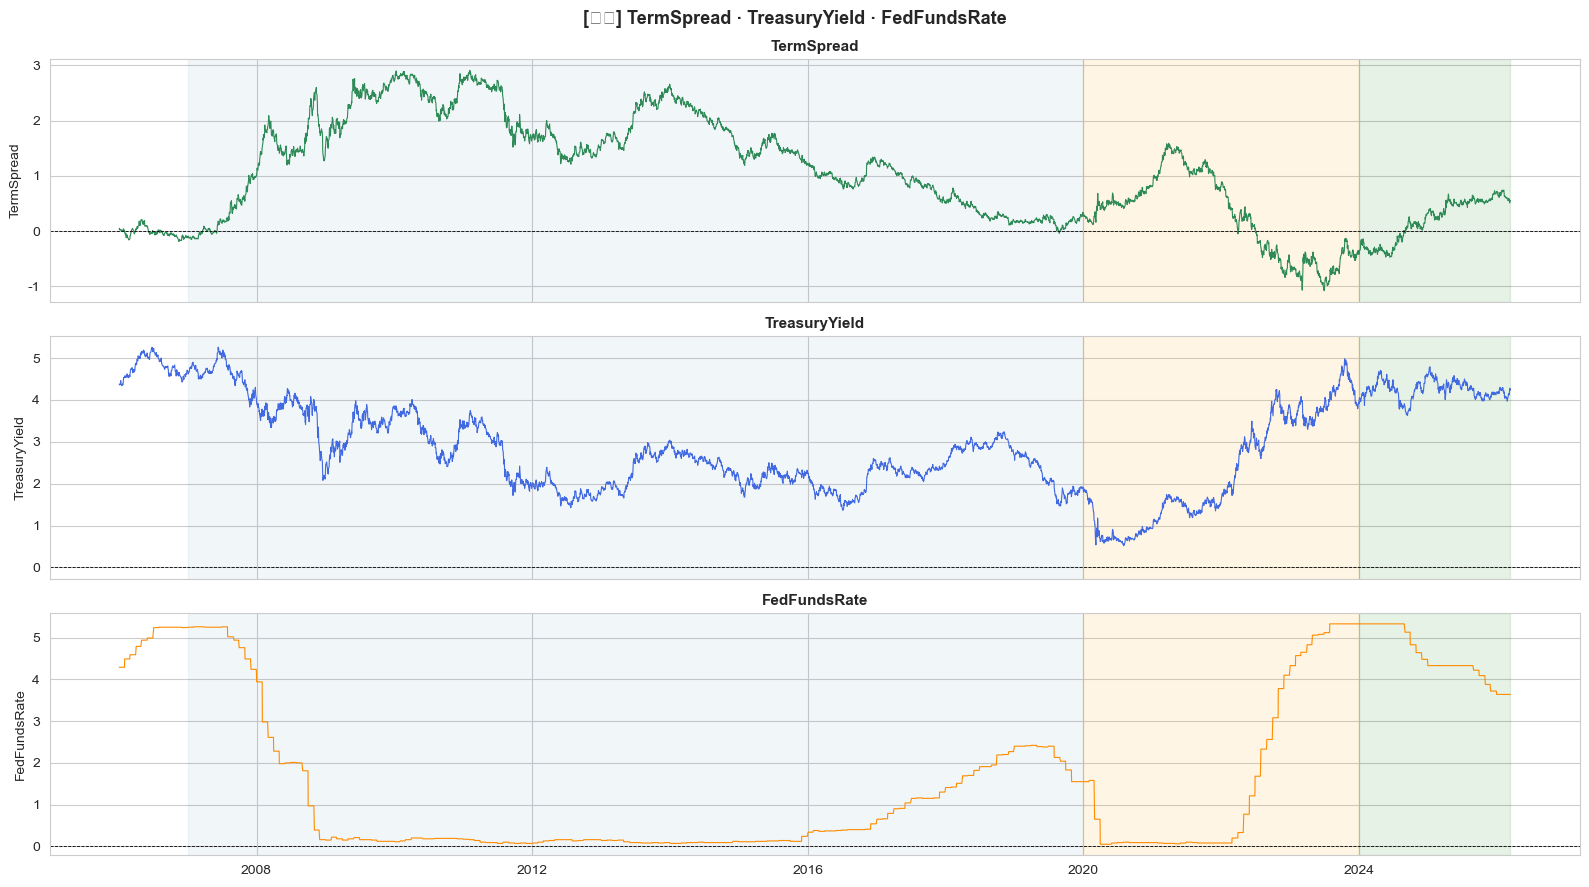

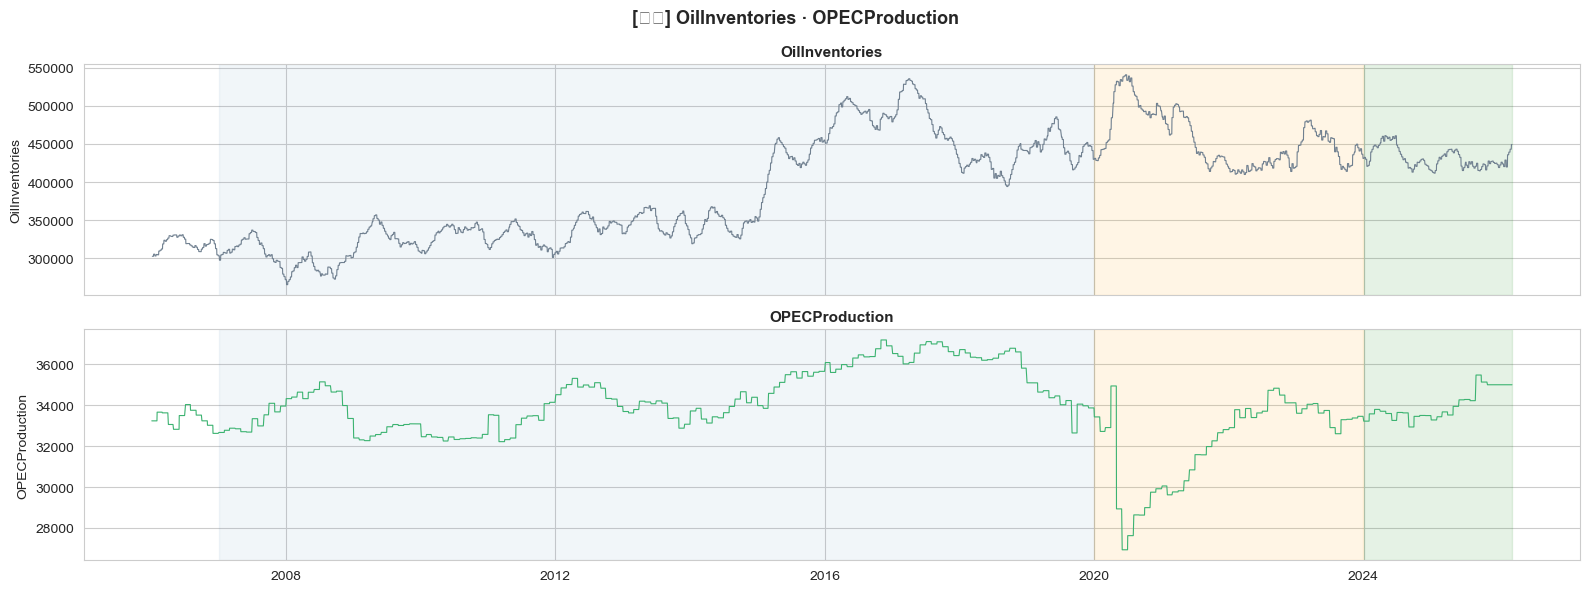

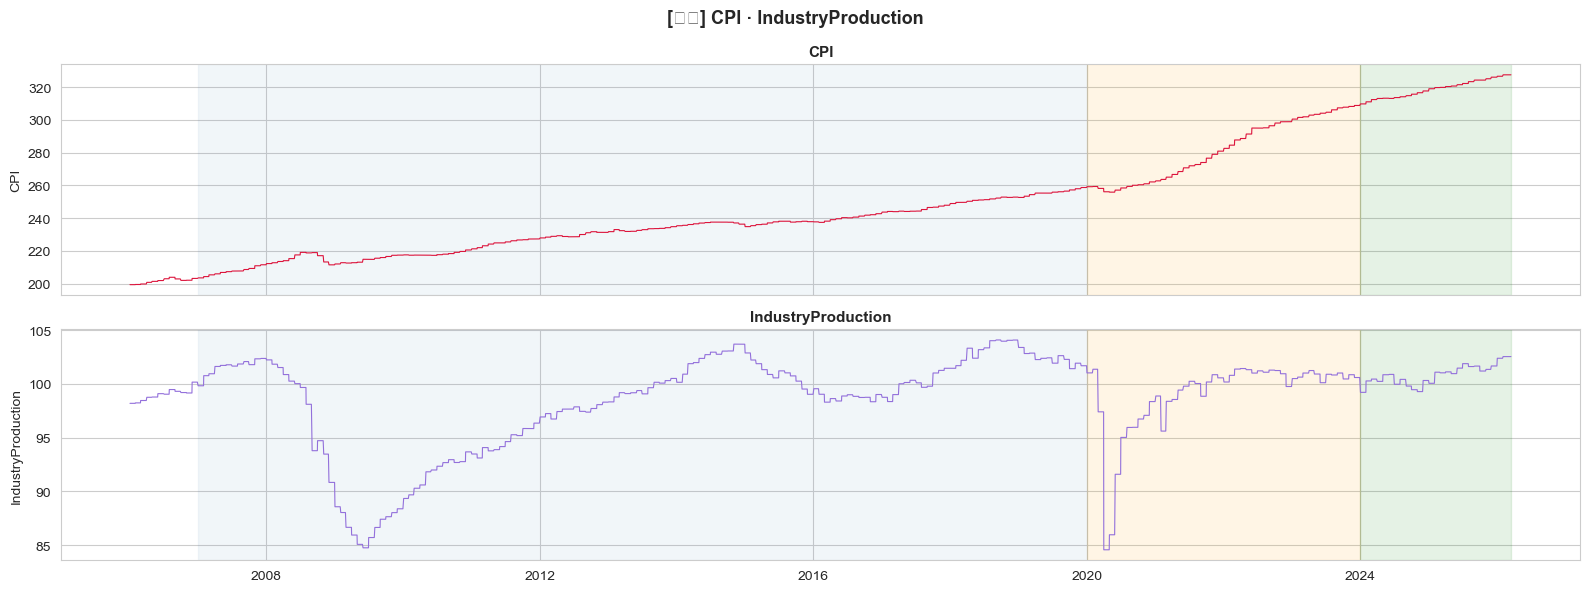

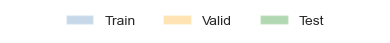

In [8]:
def add_spans(ax):
    ax.axvspan(train.index.min(), train.index.max(), alpha=0.07, color='steelblue')
    ax.axvspan(valid.index.min(), valid.index.max(), alpha=0.10, color='orange')
    ax.axvspan(test.index.min(),  test.index.max(),  alpha=0.10, color='green')

# ── 시장심리 지표: VIX, DollarIndex ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
for ax, col, color in zip(axes, ['VIX', 'DollarIndex'], ['tomato', 'steelblue']):
    s = df[col].dropna()
    ax.plot(s.index, s.values, color=color, linewidth=0.8)
    add_spans(ax)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(col)
fig.suptitle('[시장심리] VIX · DollarIndex', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 금리 지표: TermSpread, TreasuryYield, FedFundsRate ────────
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
for ax, col, color in zip(axes,
                          ['TermSpread', 'TreasuryYield', 'FedFundsRate'],
                          ['seagreen', 'royalblue', 'darkorange']):
    s = df[col].dropna()
    ax.plot(s.index, s.values, color=color, linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    add_spans(ax)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(col)
fig.suptitle('[금리] TermSpread · TreasuryYield · FedFundsRate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 공급 지표: OilInventories, OPECProduction ─────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
for ax, col, color in zip(axes, ['OilInventories', 'OPECProduction'], ['slategray', 'mediumseagreen']):
    s = df[col].dropna()
    ax.plot(s.index, s.values, color=color, linewidth=0.8)
    add_spans(ax)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(col)
fig.suptitle('[공급] OilInventories · OPECProduction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 경기 지표: CPI, IndustryProduction ───────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
for ax, col, color in zip(axes, ['CPI', 'IndustryProduction'], ['crimson', 'mediumpurple']):
    s = df[col].dropna()
    ax.plot(s.index, s.values, color=color, linewidth=0.8)
    add_spans(ax)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel(col)
fig.suptitle('[경기] CPI · IndustryProduction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 범례 안내
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.3, label='Train'),
                   Patch(facecolor='orange',    alpha=0.3, label='Valid'),
                   Patch(facecolor='green',      alpha=0.3, label='Test')]
fig_leg, ax_leg = plt.subplots(figsize=(4, 0.5))
ax_leg.legend(handles=legend_elements, loc='center', ncol=3, fontsize=10, frameon=False)
ax_leg.axis('off')
plt.tight_layout()
plt.show()

---
## 4. 타겟 변수 분포 (Train)

`oil_return_shift` 의 분포 형태와 정규성을 확인

In [9]:
target_series = train_feat[TARGET].dropna()  # 타겟 변수 : oil return shift
target_series.describe()

count    3263.000000
mean        0.000294
std         0.024042
min        -0.120382
25%        -0.011734
50%         0.000593
75%         0.011854
max         0.178376
Name: oil_return_shift, dtype: float64

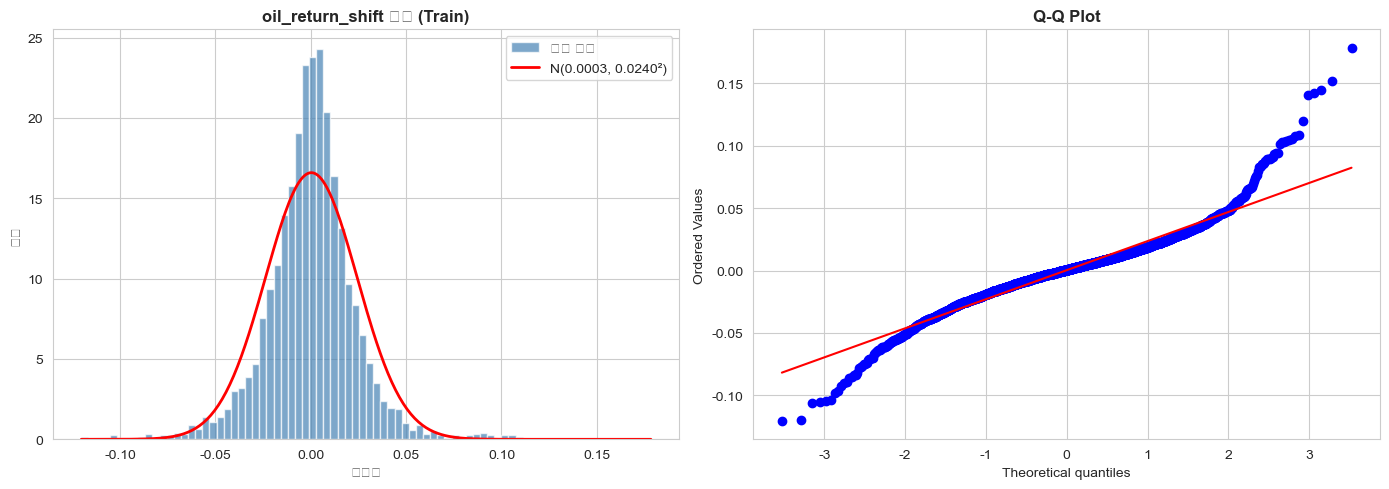

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mu, sigma = target_series.mean(), target_series.std()
x = np.linspace(target_series.min(), target_series.max(), 300)

axes[0].hist(target_series, bins=80, density=True, color='steelblue', alpha=0.7, label='실제 분포')
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'N({mu:.4f}, {sigma:.4f}²)')
axes[0].set_title('oil_return_shift 분포 (Train)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('수익률')
axes[0].set_ylabel('밀도')
axes[0].legend()

stats.probplot(target_series, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
print('평균 :', round(target_series.mean(), 6))
print('표준편차 :', round(target_series.std(), 6))
print('왜도 :', round(target_series.skew(), 4))
print('첨도 :', round(target_series.kurt(), 4))

평균 : 0.000294
표준편차 : 0.024042
왜도 : 0.3807
첨도 : 5.1926


In [12]:
up   = (target_series > 0).sum()
down = (target_series < 0).sum()
flat = (target_series == 0).sum()
total = len(target_series)

print(f'상승 : {up} ({up/total*100:.1f}%)')
print(f'하락 : {down} ({down/total*100:.1f}%)')
print(f'보합 : {flat} ({flat/total*100:.1f}%)')

상승 : 1670 (51.2%)
하락 : 1575 (48.3%)
보합 : 18 (0.6%)


* 평균 ≈ 0, 첨도가 높아 fat-tail 특성이 있음 → 정규 가정 위반 가능성
* Q-Q Plot에서 양 끝이 정규분포에서 벗어남 → 극단적 움직임이 정규 대비 더 자주 발생

---
## 5. 피처별 분포 & 기초 통계 (Train)

모멘텀 / 시장심리 / 공급 / 거시경제 그룹별로 확인

### 4-1. 모멘텀

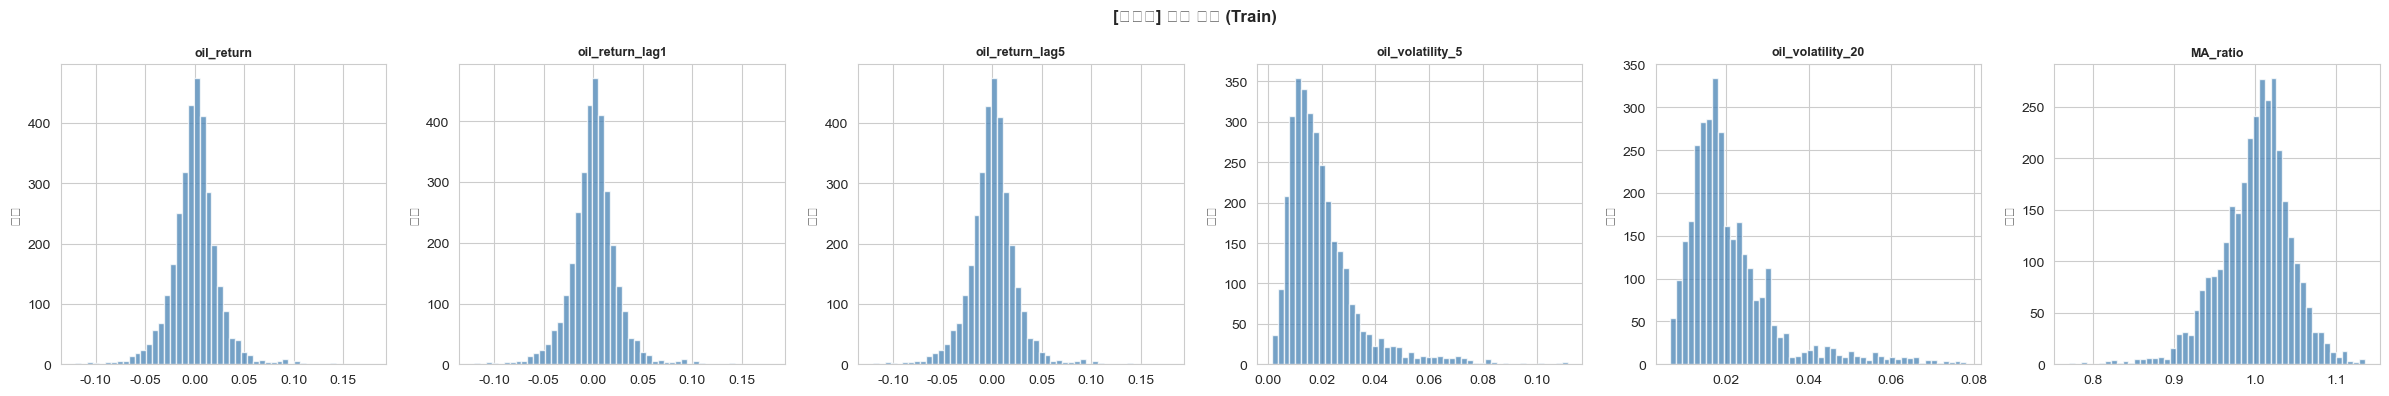

In [13]:
momentum_raw  = ['oil_return']           # OilPrice.pct_change()          → 당일 유가 수익률 (원본)
momentum_cols = [
    'oil_return_lag1',    # OilPrice.pct_change().shift(1)   → 전일 유가 수익률
    'oil_return_lag5',    # OilPrice.pct_change().shift(5)   → 5거래일 전 유가 수익률
    'oil_volatility_5',   # oil_return.rolling(5).std()      → 최근 5일 수익률 표준편차
    'oil_volatility_20',  # oil_return.rolling(20).std()     → 최근 20일 수익률 표준편차
    'MA_ratio',           # MA_5 / MA_20                     → 단기(5일)/장기(20일) 이동평균 비율
]
all_cols = momentum_raw + momentum_cols

fig, axes = plt.subplots(1, len(all_cols), figsize=(4 * len(all_cols), 4))
for ax, col in zip(axes, all_cols):
    # 파생변수는 train_feat, 원본은 train에서
    data = train_feat[col].dropna() if col in train_feat.columns else train[col].dropna()
    ax.hist(data, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('빈도')
fig.suptitle('[모멘텀] 피처 분포 (Train)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
raw_df   = train[momentum_raw].dropna()
feat_df  = train_feat[momentum_cols]
pd.concat([raw_df, feat_df], axis=1).describe().round(4)

,oil_return,oil_return_lag1,oil_return_lag5,oil_volatility_5,oil_volatility_20,MA_ratio
count,3270.0000,3263.0000,3263.0000,3263.0000,3263.0000,3263.0000
mean,0.0003,0.0003,0.0003,0.0200,0.0213,1.0004
std,0.0240,0.0240,0.0240,0.0135,0.0113,0.0438
min,-0.1204,-0.1204,-0.1204,0.0015,0.0066,0.7700
25%,-0.0117,-0.0117,-0.0117,0.0113,0.0142,0.9751
50%,0.0006,0.0006,0.0006,0.0167,0.0181,1.0052
75%,0.0118,0.0119,0.0118,0.0244,0.0247,1.0275
max,0.1784,0.1784,0.1784,0.1114,0.0781,1.1362


### 4-2. 시장심리

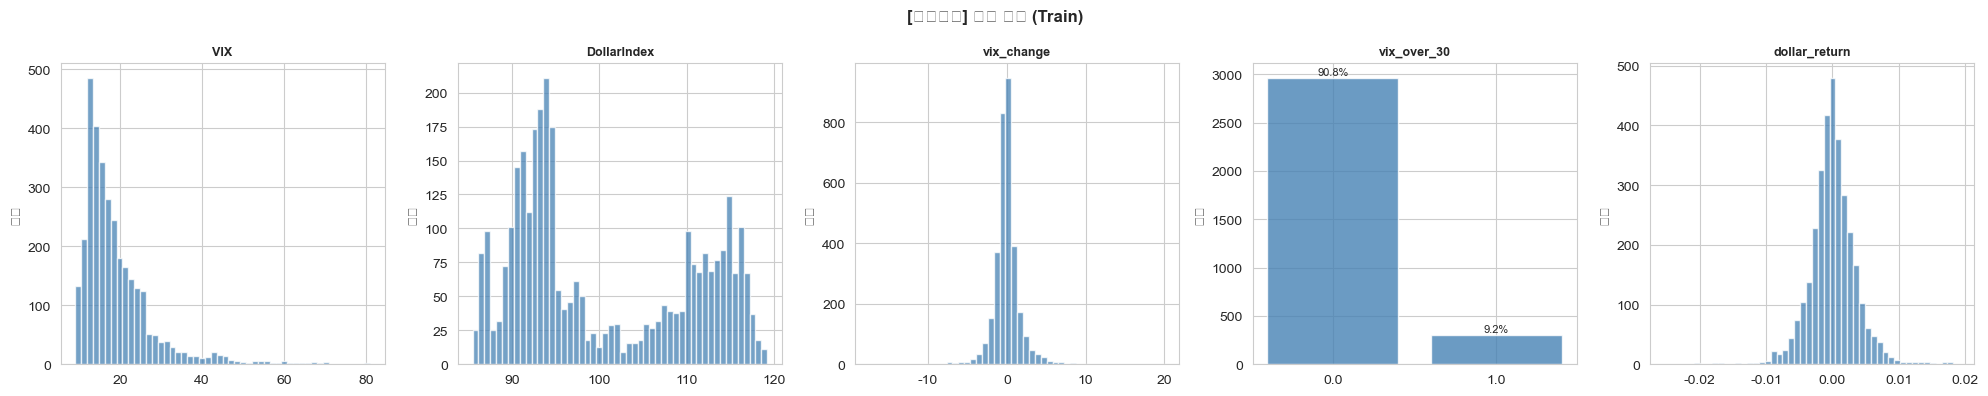

In [15]:
market_raw  = ['VIX', 'DollarIndex']   # 원본 그대로 사용
market_cols = [
    'vix_change',      # VIX.diff()                 → VIX 전일 대비 변화량
    'vix_over_30',     # (VIX > 30).astype(int)     → 시장 공포 구간 더미 (1=공포)
    'dollar_return',   # DollarIndex.pct_change()   → 달러지수 일간 변화율
]
all_cols = market_raw + market_cols

fig, axes = plt.subplots(1, len(all_cols), figsize=(4 * len(all_cols), 4))
for ax, col in zip(axes, all_cols):
    data = train_feat[col].dropna() if col in train_feat.columns else train[col].dropna()
    if data.nunique() <= 3:
        counts = data.value_counts().sort_index()
        ax.bar([str(v) for v in counts.index], counts.values, color='steelblue', alpha=0.8)
        for xi, cnt in enumerate(counts.values):
            ax.text(xi, cnt + counts.max()*0.01, f'{cnt/len(data)*100:.1f}%', ha='center', fontsize=8)
    else:
        ax.hist(data, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('빈도')
fig.suptitle('[시장심리] 피처 분포 (Train)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
raw_df  = train[market_raw].dropna()
feat_df = train_feat[market_cols]
pd.concat([raw_df, feat_df], axis=1).describe().round(4)

,VIX,DollarIndex,vix_change,vix_over_30,dollar_return
count,3266.0000,3266.0000,3263.0000,3263.0000,3263.0000
mean,19.2600,100.3621,0.0002,0.0916,0.0001
std,9.1496,10.1564,1.8740,0.2886,0.0035
min,9.1400,85.4692,-17.3600,0.0000,-0.0253
25%,13.4100,92.0986,-0.7400,0.0000,-0.0018
50%,16.5950,95.2704,-0.0900,0.0000,0.0000
75%,22.0725,111.0062,0.5700,0.0000,0.0018
max,80.8600,119.2305,20.0100,1.0000,0.0191


### 4-3. 공급

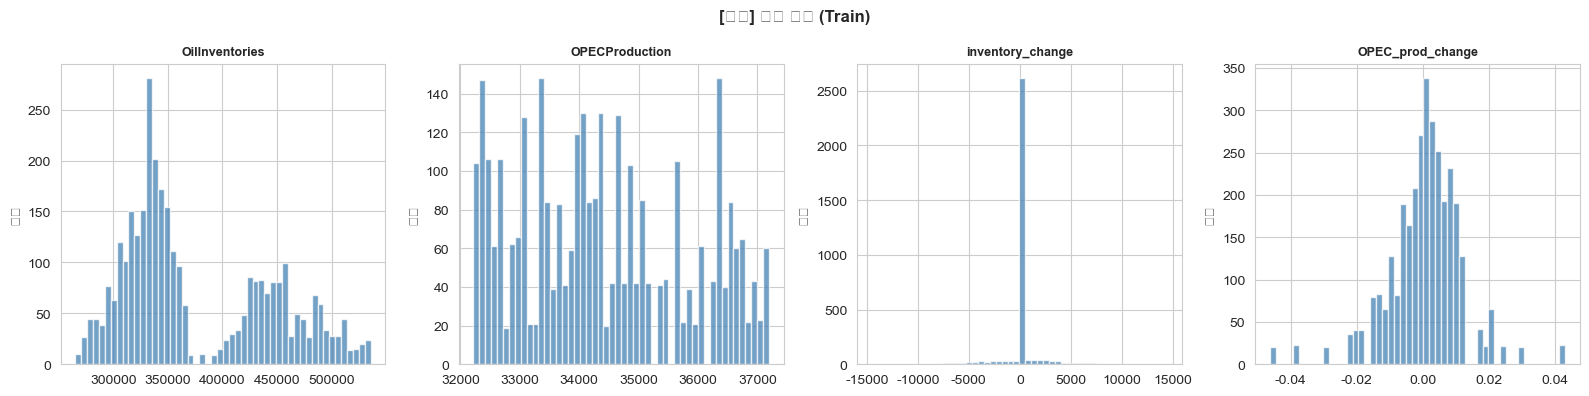

In [17]:
supply_raw  = ['OilInventories', 'OPECProduction']  # 원본 그대로 사용
supply_cols = [
    'inventory_change',   # OilInventories.diff()          → 원유 재고 전일 대비 변화량
    'OPEC_prod_change',   # OPECProduction.pct_change()    → OPEC 생산량 변화율
]
all_cols = supply_raw + supply_cols

fig, axes = plt.subplots(1, len(all_cols), figsize=(4 * len(all_cols), 4))
for ax, col in zip(axes, all_cols):
    data = train_feat[col].dropna() if col in train_feat.columns else train[col].dropna()
    ax.hist(data, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('빈도')
fig.suptitle('[공급] 피처 분포 (Train)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
raw_df  = train[supply_raw].dropna()
feat_df = train_feat[supply_cols]
pd.concat([raw_df, feat_df], axis=1).describe().round(4)

,OilInventories,OPECProduction,inventory_change,OPEC_prod_change
count,3270.0000,3270.0000,3263.0000,3263.0000
mean,376379.0131,34392.7236,38.8222,0.0004
std,68314.2669,1422.3241,2000.2007,0.0111
min,265361.0000,32221.3554,-14513.0000,-0.0463
25%,325227.0000,33131.2834,0.0000,-0.0049
50%,347466.0000,34212.5440,0.0000,0.0012
75%,438094.7500,35604.1680,0.0000,0.0062
max,535543.0000,37192.1680,14420.0000,0.0432


### 4-4. 거시경제

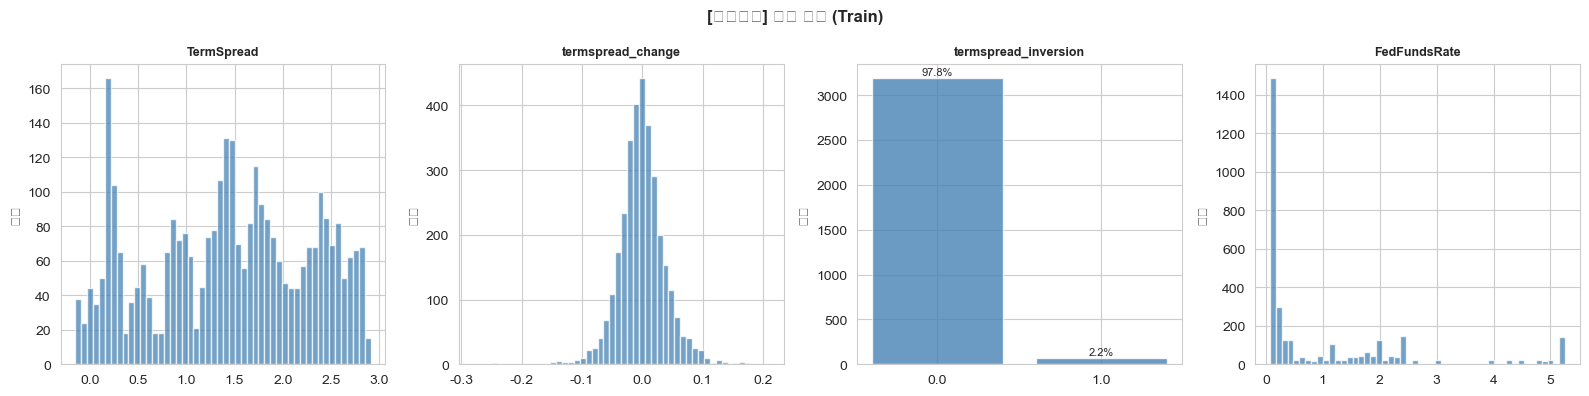

In [19]:
macro_cols = [
    'TermSpread',            # 원본 그대로 사용                 → 장단기 금리차 (10Y - 2Y)
    'termspread_change',     # TermSpread.diff()               → TermSpread 전일 대비 변화량
    'termspread_inversion',  # (TermSpread < 0).astype(int)    → 금리 역전 더미 (1=역전)
    'FedFundsRate',          # 원본 그대로 사용                 → 연방기금금리
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, macro_cols):
    data = train_feat[col].dropna()
    if data.nunique() <= 3:
        counts = data.value_counts().sort_index()
        ax.bar([str(v) for v in counts.index], counts.values, color='steelblue', alpha=0.8)
        for xi, cnt in enumerate(counts.values):
            ax.text(xi, cnt + counts.max()*0.01, f'{cnt/len(data)*100:.1f}%', ha='center', fontsize=8)
    else:
        ax.hist(data, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('빈도')
fig.suptitle('[거시경제] 피처 분포 (Train)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
train_feat[macro_cols].describe().round(4)

,TermSpread,termspread_change,termspread_inversion,FedFundsRate
count,3263.0000,3263.0000,3263.0000,3263.0000
mean,1.4397,0.0001,0.0224,1.0143
std,0.8311,0.0398,0.1479,1.4140
min,-0.1500,-0.2800,0.0000,0.0700
25%,0.8200,-0.0200,0.0000,0.1200
50%,1.4700,0.0000,0.0000,0.1900
75%,2.1400,0.0200,0.0000,1.6900
max,2.9100,0.2100,1.0000,5.2600


---
## 6. 상관관계 분석 (Train)

In [21]:
# 타겟(유가 변화율)과 각 피처 간 상관계수
corr_target = train_feat.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()
corr_target

dollar_return          -0.068569
vix_over_30            -0.031047
TermSpread             -0.008452
termspread_inversion   -0.001117
oil_volatility_20       0.009714
oil_return_lag5         0.013673
inventory_change        0.015004
FedFundsRate            0.018272
OPEC_prod_change        0.018444
termspread_change       0.029262
oil_volatility_5        0.050741
vix_change              0.068525
MA_ratio                0.144265
oil_return_lag1         1.000000
Name: oil_return_shift, dtype: float64

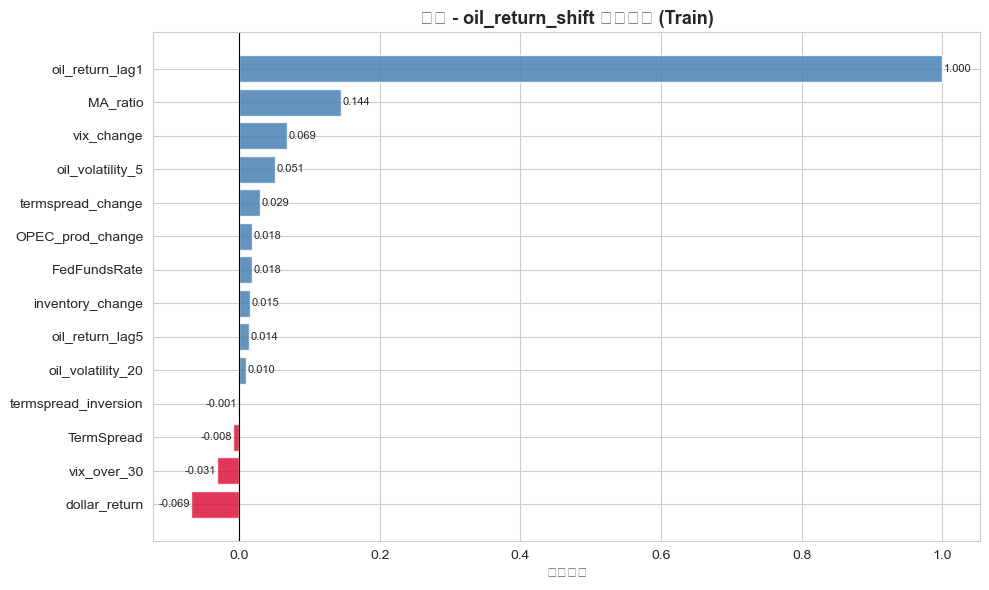

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['crimson' if v < 0 else 'steelblue' for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(corr_target.values):
    offset = 0.002 if v >= 0 else -0.002
    ax.text(v + offset, i, f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax.set_title(f'피처 - {TARGET} 상관계수 (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('상관계수')
plt.tight_layout()
plt.show()

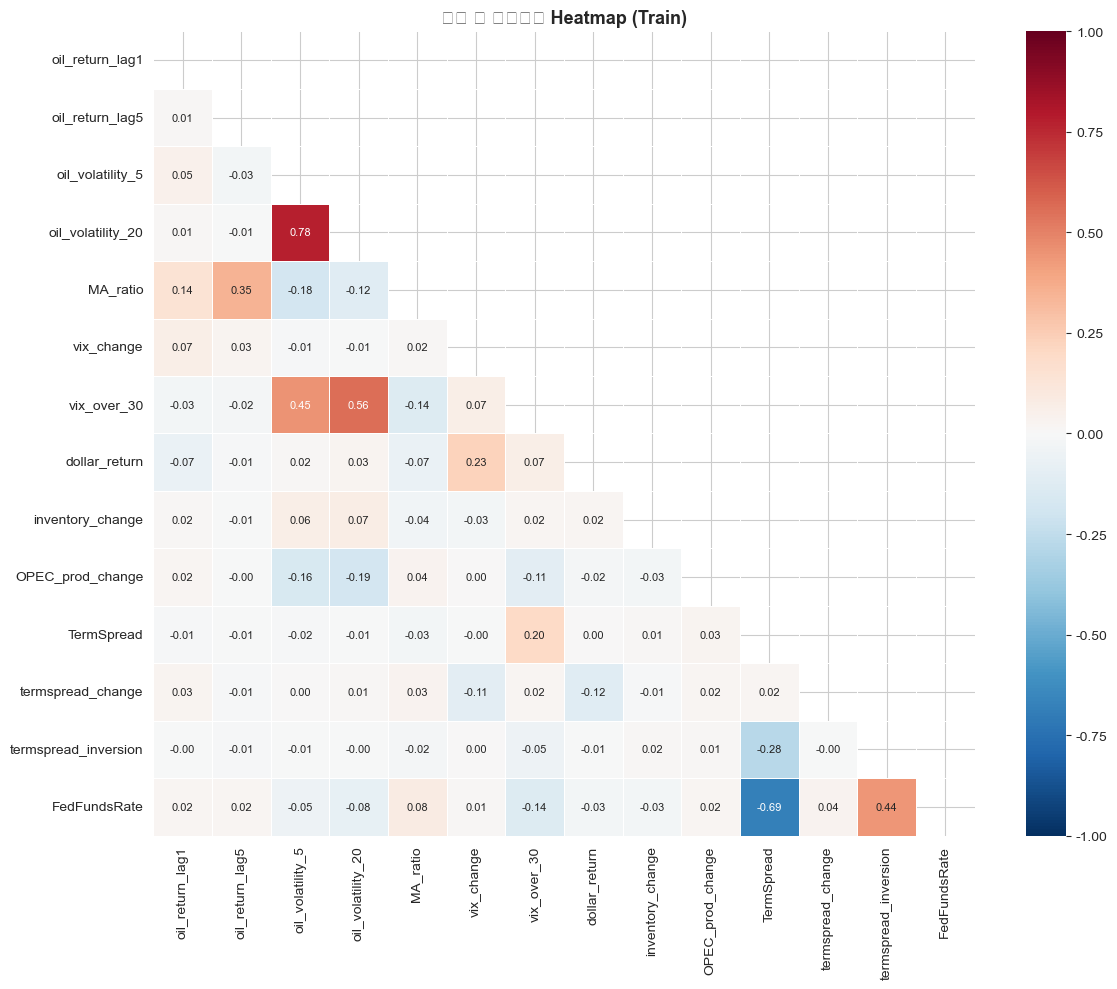

In [23]:
# 피처 간 상관관계 heatmap
corr_matrix = train_feat[FEATURES].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8}, ax=ax)
ax.set_title('피처 간 상관관계 Heatmap (Train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* 대부분 피처가 타겟과 낮은 선형 상관을 보임 → 비선형 모델(트리, 신경망) 고려 필요
* |r| > 0.7인 피처 쌍은 섹션 7 VIF에서 다중공선성을 정밀 확인

---
## 7. 이벤트 구간 분석 (Train)

유가 수익률에 영향을 줄 수 있는 **3가지 특수 상황**을 boxplot으로 비교한다.

| 이벤트 | 피처 | 분석 목적 |
|--------|------|-----------|
| 공포 구간 | `vix_over_30 == 1` | 시장 공포 시 유가 변동성 확대 여부 확인 |
| 장단기 금리 역전 | `termspread_inversion == 1` | 경기침체 신호와 유가 수익률 관계 확인 |
| OPEC 감산 | 2014.11 ~ 2015.12 | 공급 감산 발표 이후 유가 방향성 확인 |

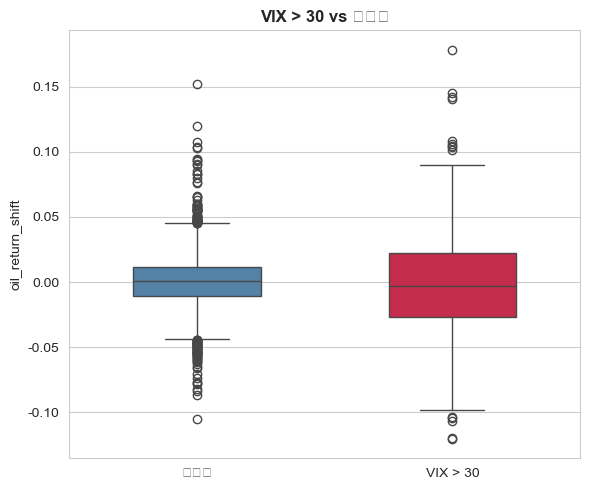

In [24]:
# VIX > 30 vs 평상시
vix_data = train_feat[['vix_over_30', TARGET]].dropna().copy()
vix_data['구간'] = vix_data['vix_over_30'].map({1.0: 'VIX > 30', 0.0: '평상시'})

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=vix_data, x='구간', y=TARGET, hue='구간',
            palette={'VIX > 30': 'crimson', '평상시': 'steelblue'},
            order=['평상시', 'VIX > 30'], width=0.5, legend=False, ax=ax)
ax.set_title('VIX > 30 vs 평상시', fontsize=12, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [25]:
vix_data.groupby('구간')[TARGET].agg(['count', 'mean', 'std']).round(4)

,count,mean,std
구간,,,
VIX > 30,299,-0.0021,0.0451
평상시,2964,0.0005,0.0208


**VIX > 30 Insight**

* Train 기간(2007-2019) 중 VIX > 30 구간은 **299일**로, 주로 2008 금융위기·2011 유럽 재정위기·2015-2016 원자재 위기 구간에 집중됨
* 평균 수익률: 평상시 **+0.05%** vs VIX > 30 **-0.21%** → 공포 구간에서 유가 하락 편향이 나타남
* 표준편차: 평상시 **2.08%** vs VIX > 30 **4.51%** → 변동성이 약 **2.2배** 확대
* VIX > 30은 단순한 노이즈가 아니라 실질적인 하방 리스크 신호로 해석 가능 → 모델 피처로서 활용 가치 있음

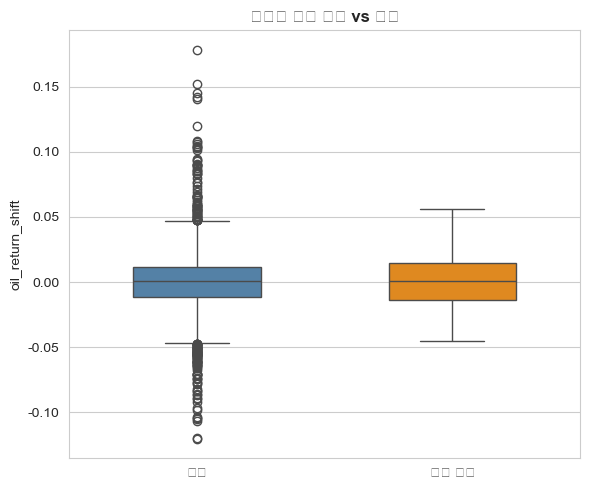

In [26]:
# 장단기 금리 역전 vs 정상
ts_data = train_feat[['termspread_inversion', TARGET]].dropna().copy()
ts_data['구간'] = ts_data['termspread_inversion'].map({1.0: '금리 역전', 0.0: '정상'})

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=ts_data, x='구간', y=TARGET, hue='구간',
            palette={'금리 역전': 'darkorange', '정상': 'steelblue'},
            order=['정상', '금리 역전'], width=0.5, legend=False, ax=ax)
ax.set_title('장단기 금리 역전 vs 정상', fontsize=12, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [27]:
ts_data.groupby('구간')[TARGET].agg(['count', 'mean', 'std']).round(4)

,count,mean,std
구간,,,
금리 역전,73,0.0001,0.0212
정상,3190,0.0003,0.0241


**장단기 금리 역전 구간 Insight**

* Train 기간 중 금리 역전 구간은 **73일**로 매우 제한적 (주로 2019년 하반기)
* 평균 수익률: 정상 **+0.03%** vs 금리 역전 **+0.01%** → 차이가 미미함
* 표준편차: 정상 **2.41%** vs 금리 역전 **2.12%** → 오히려 변동성이 소폭 낮음
* Train 기간 내 금리 역전 사례가 적어 통계적 유의성이 낮음
* 단, 금리 역전은 경기침체 선행 지표로 알려져 있어 **중장기 시계열 맥락**에서 의미 있을 수 있음 → Test 구간(2020~)에서 영향 재확인 필요

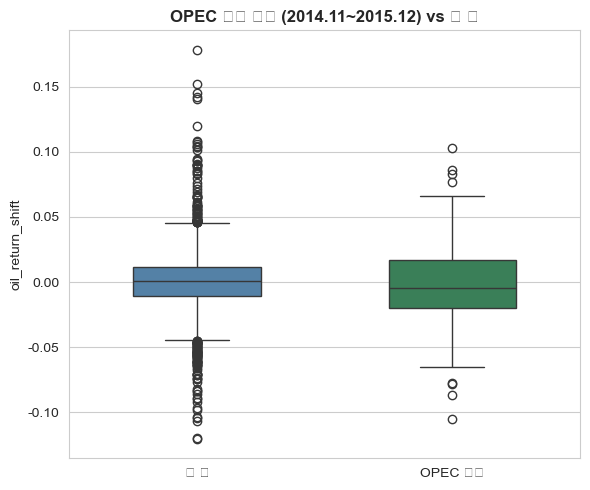

In [28]:
# OPEC 감산 구간 (2014.11 ~ 2015.12)
opec_data = train_feat[[TARGET]].copy()
opec_mask = (opec_data.index >= '2014-11-01') & (opec_data.index <= '2015-12-31')
opec_data['구간'] = np.where(opec_mask, 'OPEC 감산', '그 외')

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=opec_data, x='구간', y=TARGET, hue='구간',
            palette={'OPEC 감산': 'seagreen', '그 외': 'steelblue'},
            order=['그 외', 'OPEC 감산'], width=0.5, legend=False, ax=ax)
ax.set_title('OPEC 감산 구간 (2014.11~2015.12) vs 그 외', fontsize=12, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [29]:
opec_data.groupby('구간')[TARGET].agg(['count', 'mean', 'std']).round(4)

,count,mean,std
구간,,,
OPEC 감산,293,-0.0023,0.0293
그 외,2970,0.0005,0.0235


**[OPEC 감산 구간 해석]**

* 2014년 11월 OPEC은 감산을 거부하고 생산량을 유지하기로 결정 → 공급 과잉 우려로 유가 급락
* 해당 구간(293일) 평균 수익률: 그 외 **+0.05%** vs OPEC 감산 **-0.23%** → 뚜렷한 하락 편향
* 표준편차: 그 외 **2.35%** vs OPEC 감산 **2.93%** → 변동성도 약 **1.25배** 확대
* OPEC 결정이 단기 수익률뿐만 아니라 변동성에도 영향을 미쳤음을 확인
* `OPEC_prod_change` 피처는 이런 공급 측 충격을 포착하는 변수로, 유가 방향성 예측에 기여할 수 있음

**[종합 인사이트]**

| 이벤트 | 평균 수익률 차이 | 변동성 변화 | 피처 활용 가치 |
|--------|----------------|------------|--------------|
| VIX > 30 | -0.21% vs +0.05% | **2.2배** 확대 | 높음 |
| 금리 역전 | +0.01% vs +0.03% | 소폭 감소 | 낮음 (Train 내 사례 부족) |
| OPEC 감산 | -0.23% vs +0.05% | **1.25배** 확대 | 높음 |

* VIX와 OPEC 공급 변수는 유가 수익률의 **방향성과 변동성** 모두에 유의미한 영향을 보임
* 금리 역전 변수는 Train 기간에서 사례가 적어 효과가 제한적이나, 2022~2023년 급격한 금리 역전 국면이 포함된 Valid/Test 구간에서 중요해질 수 있음
* 이벤트 구간에서 변동성이 확대되는 특성은 **heteroscedasticity(이분산성)** 를 시사 → GARCH 계열 모델이나 변동성 피처 추가를 고려할 수 있음

---
## 8. VIF 다중공선성 확인 (Train)

VIF = 1/(1-R²) 로 각 피처가 나머지 피처들에 의해 얼마나 설명되는지를 측정한다.

| VIF 범위 | 판정 |
|----------|------|
| < 5 | 양호 |
| 5 ~ 10 | 주의 |
| ≥ 10 | 다중공선성 높음 → 처리 필요 |

In [30]:
# statsmodels 없이 numpy로 VIF 직접 계산
def compute_vif(X):
    vifs = []
    for i in range(X.shape[1]):
        y_i = X[:, i]
        X_rest = np.column_stack([np.ones(len(y_i)), np.delete(X, i, axis=1)])
        beta, _, _, _ = np.linalg.lstsq(X_rest, y_i, rcond=None)
        y_hat = X_rest @ beta
        ss_res = np.sum((y_i - y_hat) ** 2)
        ss_tot = np.sum((y_i - y_i.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
        vifs.append(1.0 / (1.0 - r2) if r2 < 1 - 1e-12 else np.inf)
    return vifs

In [31]:
vif_base = train_feat[FEATURES].dropna()
vif_cols = [c for c in vif_base.columns if vif_base[c].std() > 1e-12]
X_vif = vif_base[vif_cols].values.astype(float)

vif_df = pd.DataFrame({'Feature': vif_cols, 'VIF': compute_vif(X_vif)})
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_df

,Feature,VIF
0,oil_volatility_20,3.075257
1,oil_volatility_5,2.642979
2,FedFundsRate,2.256191
3,TermSpread,2.034568
4,vix_over_30,1.579890
5,termspread_inversion,1.250591
6,MA_ratio,1.232750
7,oil_return_lag5,1.142794
8,vix_change,1.083076
9,dollar_return,1.083069


In [32]:
# VIF ≥ 10 빨강, ≥ 5 노랑 강조
def highlight_vif(row):
    if row['VIF'] >= 10:
        return ['background-color: #ff6b6b; color: white'] * len(row)
    elif row['VIF'] >= 5:
        return ['background-color: #ffd93d'] * len(row)
    return [''] * len(row)

vif_df.style.apply(highlight_vif, axis=1).format({'VIF': '{:.2f}'})

,Feature,VIF
0,oil_volatility_20,3.08
1,oil_volatility_5,2.64
2,FedFundsRate,2.26
3,TermSpread,2.03
4,vix_over_30,1.58
5,termspread_inversion,1.25
6,MA_ratio,1.23
7,oil_return_lag5,1.14
8,vix_change,1.08
9,dollar_return,1.08


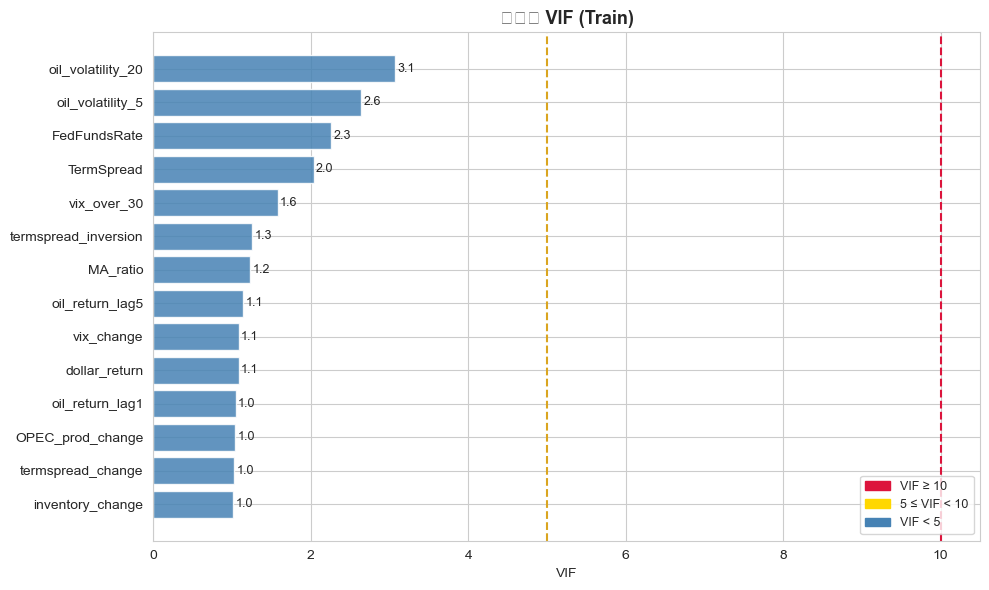

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['crimson' if v >= 10 else 'gold' if v >= 5 else 'steelblue' for v in vif_df['VIF']]
bars = ax.barh(vif_df['Feature'], vif_df['VIF'], color=bar_colors, alpha=0.85)

ax.axvline(10, color='crimson',   linestyle='--', linewidth=1.5, label='VIF=10')
ax.axvline(5,  color='goldenrod', linestyle='--', linewidth=1.5, label='VIF=5')

x_max = vif_df['VIF'].replace(np.inf, np.nan).max()
for bar, val in zip(bars, vif_df['VIF']):
    label = f'{val:.1f}' if not np.isinf(val) else '∞'
    ax.text(min(val, x_max) + x_max * 0.01, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='crimson',   label='VIF ≥ 10'),
    mpatches.Patch(color='gold',      label='5 ≤ VIF < 10'),
    mpatches.Patch(color='steelblue', label='VIF < 5'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
ax.set_title('피처별 VIF (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('VIF')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**[VIF 결과 해석]**

* **모든 피처의 VIF < 5** → 심각한 다중공선성 없음, 전체 피처를 그대로 사용 가능

* **VIF 상위 피처 분석**

  | 피처 | VIF | 해석 |
  |------|-----|------|
  | `oil_volatility_20` | 3.08 | 20일 변동성과 5일 변동성이 겹치는 정보를 가짐 |
  | `oil_volatility_5`  | 2.64 | 위와 같음 — 두 변수 동반 사용 시 상호 설명력 존재 |
  | `FedFundsRate`      | 2.26 | TermSpread(장단기 금리차)와 수준 방향이 유사한 구간 존재 |
  | `TermSpread`        | 2.03 | FedFundsRate, TreasuryYield와 일부 정보 중복 |

* **실용적 판단**
  * 트리 기반 모델(XGBoost, LightGBM 등)은 다중공선성에 강건하므로 **피처 제거 없이 사용 가능**
  * 선형 회귀 등 계수 해석이 중요한 모델을 사용할 경우 `oil_volatility_5`와 `oil_volatility_20` 중 하나를 선택하거나 PCA로 압축하는 방법을 고려
  * `FedFundsRate`와 `TermSpread`는 각각 단기 금리 수준과 기간 구조를 나타내어 **경제적 의미가 달라 함께 유지**하는 것이 적절

---
## EDA 요약

| 항목 | 주요 발견 |
|------|----------|
| 타겟 분포 | 평균 ≈ 0, 첨도 높음(fat-tail), 정규 가정 위반 |
| 피처-타겟 상관 | 대부분 낮은 선형 상관 → 비선형 모델 고려 |
| 이벤트 영향 | VIX>30 변동성 확대, OPEC 감산 후 하락 지속 |
| 다중공선성 | VIF ≥ 10 변수 존재 → 모델에 따라 처리 필요 |

---
## 데이터 저장

개장일 필터링 + 결측치 제거한 최종 데이터를 `F_Final.csv`로 저장

In [34]:
# df는 이미 is_trading_day == 1 필터링 완료
# missing_reason은 거래일에서 항상 NaN이므로 제거 후 dropna
df_final = df.drop(columns=['missing_reason']).dropna()

df_final.reset_index().to_csv(
    '../datas/Finance_Final/F_Final.csv',
    index=False,
    encoding='utf-8-sig'
)

df_final.head(3)

,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,...,vix_over_30,inventory_change,termspread_change,termspread_inversion,TermSpread_sign,OPEC_prod_change,is_monday,is_friday,is_trading_day,is_non_trading_day
date,,,,,,,,,,,,,,,,,,,,,
2007-01-04,55.65,2.148076,203.437,97.5251,11.51,99.8346,11181.0,303219.0,32670.334,5369.0,...,0.0,0.0,0.00,1.0,-1.0,0.001371,0.0,0.0,1.0,0
2007-01-05,56.29,2.148076,203.437,97.7801,12.14,99.8346,11181.0,297470.0,32670.334,5370.0,...,0.0,-5749.0,-0.02,1.0,-1.0,0.001371,0.0,1.0,1.0,0
2007-01-08,56.08,2.148076,203.437,97.7880,12.00,99.8346,11181.0,297470.0,32670.334,5370.0,...,0.0,0.0,-0.01,1.0,-1.0,0.001371,1.0,0.0,1.0,0
